# Other emission models

This notebook explains how to use and implement emission models that are **NOT** hot regions at the surface of Neutron Stars. Such models can be fixed or fitted alongside the usual hot region and spacetime parameters. Here, we provide a simple model that can be fitted to data.

Note that such emission models need to be handled with care for various reasons. For instance, using such models can introduce large errors and bias when the background of the data is not well defined. This is because part of the emission model can be mistaken for background during inference, which in turn bias parameter estimation of the emission model components and hence of the hot spot parameters and ultimately of the mass and radius. This phenomenon has been observed to happen in every test run that used background marginalization likelihood alongside poorly defined background. Moreover, the proposed power law model here is not physical, but rather phenomenological. Hence, as it is poorly understood, the chosen spectral and pulse shapes may be wrong, which would result in biased mass and radius.  

To run this tutorial, all data files should be available in in the directory `examples/examples_modeling_tutorial/model_data/`. It is also recommended to have basic knowledge of X-PSI before reading this notebook, by reading the `XPSI_101`, `Modeling`, and/or `Modeling_without_statistics` tutorials. 

In [1]:
%matplotlib inline

import math, os
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rcParams
rcParams['text.usetex'] = False
rcParams['font.size'] = 14.0

import xpsi

from xpsi.global_imports import gravradius

/=============================================\
| X-PSI: X-ray Pulse Simulation and Inference |
|---------------------------------------------|
|                Version: 3.3.0               |
|---------------------------------------------|
|      https://xpsi-group.github.io/xpsi      |
\=============================================/

Imported emcee version: 3.1.4
Imported PyMultiNest.
Imported UltraNest.
Imported GetDist version: 1.4.7
Imported nestcheck version: 0.2.1


# Emission models

Here is a rundown of the the tools available with the emission models and how to setup one yourself.

A powerlaw model, that can be pulsed or not, is provided out of the box. Here is how to instansiate it using the usual X-PSI nomenclature for ParametersSubspace, with `values` and `bounds`. Its flux is as follows: $$F(E) = K \times \left( \frac{E}{\rm 1keV} \right)^{-\Gamma}$$

where E is the energy, K is the normalization of the powerlaw (its flux at 1keV), and $\Gamma$ is the photon index of the power law (dimensionless). 

In [2]:
bounds = {}
values = {'norm':1e-5, 
          'gamma':1.5,
          }
PowerLaw = xpsi.PowerLaw(bounds=bounds,
                        values=values)

Creating parameter:
    > Named "norm" with fixed value 1.000e-05.
    > Normalization of the PowerLaw in photons/cm2/s/keV @ 1keV.
Creating parameter:
    > Named "gamma" with fixed value 1.500e+00.
    > Photon index of the PowerLaw.
Creating parameter:
    > Named "phase_shift" with fixed value 0.000e+00.
    > Phase shift of the PowerLaw.


By default, `PowerLaw` uses 5 phase bins. This a minimum required by X-PSI, as the energy integrator used has been made for 2D arrays and only works with a minimum of 5 phase values. 

After the emission model `integrate` function has been called, the attribute `signal` is set. Let's check what it looks like.

In [3]:
# Integrate the model
energies = np.logspace(0.0, np.log10(3.0), 50)
PowerLaw.integrate(energies=energies, threads=1)
print( PowerLaw.signal[0].shape ) # To be X-PSI compliant, the signal is a tuple containing a single 2D array with shape (number of energies, number of phases)

(50, 5)


In [4]:
# Helper function for plotting signal
def plotSignal( energies, model , title=None , log=True):

    im = plt.pcolormesh( energies, model.phases, model.signal[0].T[:-1, :-1], shading='flat')
    plt.xlabel('Energy [keV]')
    plt.ylabel('Phase') 
    plt.colorbar(im, label='Flux [photon/cm^2/s/keV]')
    if title is not None:
        plt.title(title)
    plt.show() 

    # Now the signal as a function of energy integrated oved phase bins. As it is phase independent, we retrieve the powerlaw
    phase_integrated_signal = np.trapz( y=model.signal[0], x = model.phases )
    print( model.phases.shape, model.signal[0].shape )
    plt.loglog(energies, phase_integrated_signal, label='Bin centers')
    plt.step(energies, phase_integrated_signal, where='mid', alpha=0.7,  label='Bins')
    plt.xlabel('Energy [keV]')
    plt.ylabel('Flux [photon/cm^2/s/keV]')
    if not log:
        plt.xscale('linear')
        plt.yscale('linear') 
    plt.legend()
    if title is not None:
        plt.title(title)
    plt.show()

    # Now the signal as a function of phase integrated oved energy bins
    energy_integrated_signal = np.trapz( y=model.signal[0].T, x = energies )
    plt.plot(model.phases, energy_integrated_signal, label='Bin centers')
    plt.step(model.phases, energy_integrated_signal, where='mid', alpha=0.7,  label='Bins')
    plt.xlabel('Phase')
    plt.ylabel('Flux [photon/cm^2/s]')
    plt.legend()    
    if title is not None:
        plt.title(title)
    plt.show()

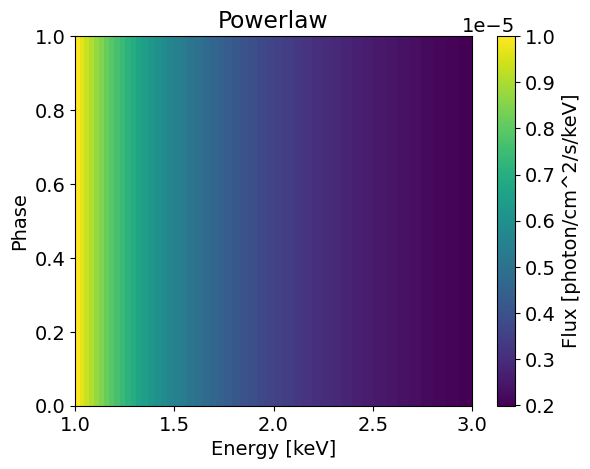

(5,) (50, 5)


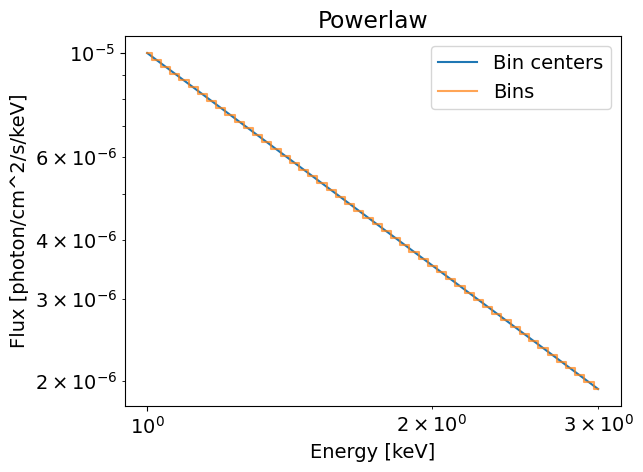

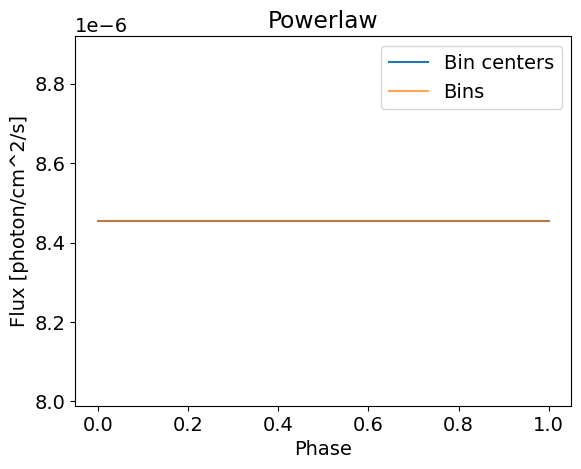

In [5]:
# Plot the signal
plotSignal( energies, PowerLaw, title='Powerlaw' ) # The signal is phase independent so we see no variation with phase

The flux in all the phase bins equals to 1e-5 photons/cm^2/s/keV at 1keV in the first figure. When we integrate over the phases from zero to one, we keep this value since the flux is constant across the phase array. In this phase integrated case, we retrieve a simple power law shape.

It is also possible to use a sinusoidal pulsed power law model. This model is defined as: $$F(E) = K \times \left( \frac{E}{\rm 1keV} \right)^{-\Gamma} \left[ 1 + A \times \cos( 2\pi (\phi - \phi_0)) \right]$$

Where A is the amplitude of the oscialltion and $\phi_0$ the phase center. This model can be imported as follows:

In [6]:
bounds = {}
values = {'norm':1e-5, 
          'gamma':1.5, 
          'oscillation_amplitude':0.2, 
          'phase_shift':0.2}
PulsedPowerLaw = xpsi.PowerLaw(bounds=bounds,
                        values=values,
                        pulsed=True,    # Requires the model to be pulsed
                        num_leaves=32,  # Number of phase bins to use for model computation
                        )

Creating parameter:
    > Named "norm" with fixed value 1.000e-05.
    > Normalization of the PowerLaw in photons/cm2/s/keV @ 1keV.
Creating parameter:
    > Named "gamma" with fixed value 1.500e+00.
    > Photon index of the PowerLaw.
Creating parameter:
    > Named "oscillation_amplitude" with fixed value 2.000e-01.
    > Amplitude of oscillation of the PowerLaw.
Creating parameter:
    > Named "phase_shift" with fixed value 2.000e-01.
    > Phase shift of the PowerLaw.


(50, 32)


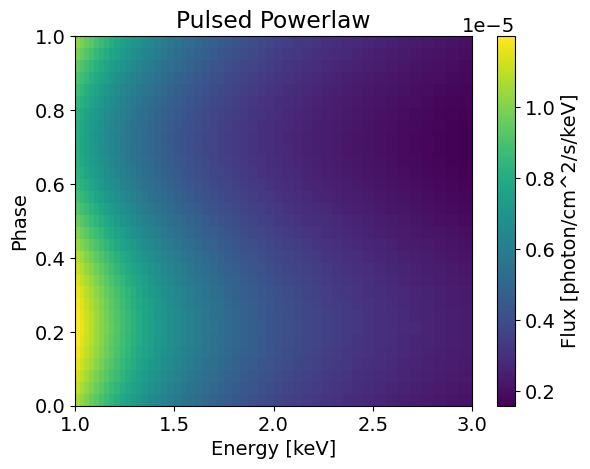

(32,) (50, 32)


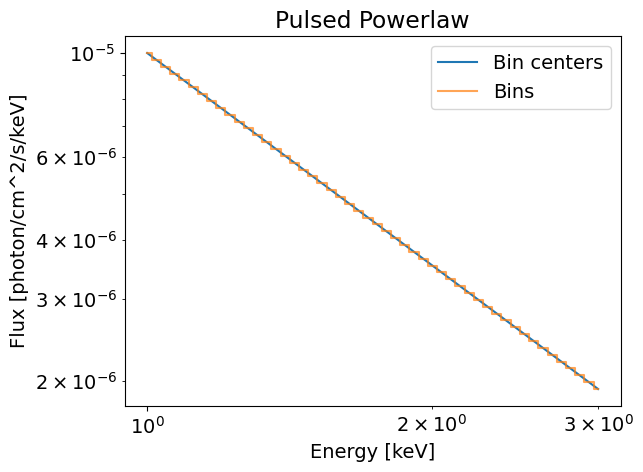

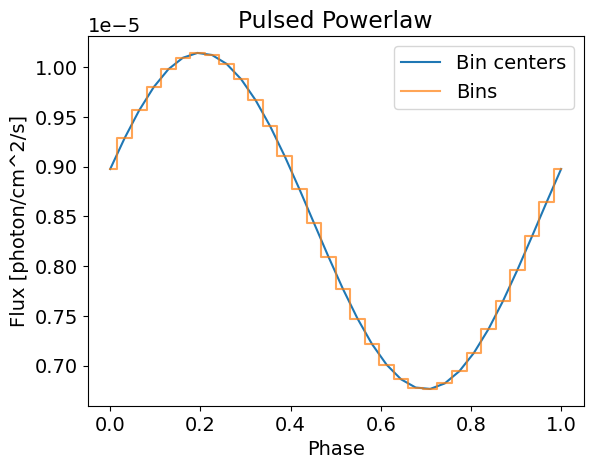

In [7]:
# Integrate the model
energies = np.logspace(0.0, np.log10(3.0), 50)
PulsedPowerLaw.integrate(energies=energies, threads=1)
print( PulsedPowerLaw.signal[0].shape ) # To be X-PSI compliant, the signal is a tuple containing a single 2D array with shape (number of energies, number of phases)

# Plot the signal
plotSignal( energies, PulsedPowerLaw, title='Pulsed Powerlaw' ) # The signal depends on phase now, so we see a pulse

This time, we retrieve the same power law spectrum because the pulsed component is sinusoidal it averages to 0 over [0;1]. However, we can see clear modulation with a defined pulse when integrating over the energies.

Note that the powerlaw is shifted by 0.2 phases as required. This is different from hot spots, for which the phase shift is not applied during integration, but rather when the signals from all components are added up in the call of the likelihood. Emission models have been implemented this way for simplicity of writting and testing custom emission models.

If you wish to write your own, any other emission model can be built from the base `EmissionModel` class. It requires a `phase_shift` parameter and the definition of an `integrate` method, which computes the flux from the model in [photon/cm^2/s]. If needed, a `embed` method can be created to embed the emission model into the ambiant spacetime, which is relevant to precompute cells at the surface of an oblate neutron star for instance. The base `EmissionModel` class comes with helper function to properly build a signal that can be used by X-PSI. 

Here is an example of a Gaussian.

In [8]:
from xpsi import Parameter, EmissionModel 
class GaussianModel( EmissionModel ):

    """ Simple Gaussian line emission model."""

    required_names = ['norm',
                      'E0',
                      'sigma',
                      'phase_shift']
    
    def __init__(self, 
                 bounds,
                 values,
                 **kwargs):

        # Initiate the necessary parameters
        norm = Parameter('norm',
                        strict_bounds = (0.0, np.infty),
                        bounds = bounds.get('norm', None),
                        doc = "Flux of the Gaussian @E0 keV in [photon/cm^2/s/keV]",
                        symbol = 'norm',
                        value = values.get('norm', None))
        
        E0 = Parameter('E0',
                strict_bounds = (0.0, np.infty),
                bounds = bounds.get('E0', None),
                doc = "Energy center of the Gaussian in [keV]",
                symbol = r'$E_0$',
                value = values.get('E0', None))
        
        sigma = Parameter('sigma',
                strict_bounds = (1e-10, np.infty),
                bounds = bounds.get('sigma', None),
                doc = "Energy width of the Gaussian in [keV]",
                symbol = r'$\sigma$',
                value = values.get('sigma', None))
        
        # Define a fixed phase shift
        phase_shift = Parameter('phase_shift',
                strict_bounds = (0. , 1.),
                bounds = None,
                doc = "Phase shift of the Gaussian",
                symbol = r'$\phi_0$',
                value = 0.)
        
        # Set the value of num_leaves
        self._num_leaves = 5 # Default to 5 so that energy integrator works
        self._phases =  np.linspace(0.0, 1.0, int(self._num_leaves))

        # Initiate the parent class
        super(GaussianModel, self).__init__( norm, E0, sigma, phase_shift, **kwargs ) # prefix in kwargs

    # The integrate method is needed by X-PSI to compute the signal
    # Also, the helper function from the base class is present here to build the signal properly
    def integrate(self, energies, threads, *args, **kwargs):
        
        # Compute the Gaussian
        gaussian = self['norm'] * np.exp( -0.5 * np.power( (energies - self['E0']) / self['sigma'], 2.0 ) )
        self.signal = self.buildPhaseIndependentSignal( gaussian ) # Helper function to build the signal in a phase independent way

Now the Gaussian model can be instanciated easily, as it was the case for the PowerLaw.

In [9]:
bounds = {}
values = {'norm':1e-5, 
          'E0':2.0,
          'sigma':0.15,
          }
Gaussian = GaussianModel(bounds=bounds,
                        values=values)

Creating parameter:
    > Named "norm" with fixed value 1.000e-05.
    > Flux of the Gaussian @E0 keV in [photon/cm^2/s/keV].
Creating parameter:
    > Named "E0" with fixed value 2.000e+00.
    > Energy center of the Gaussian in [keV].
Creating parameter:
    > Named "sigma" with fixed value 1.500e-01.
    > Energy width of the Gaussian in [keV].
Creating parameter:
    > Named "phase_shift" with fixed value 0.000e+00.
    > Phase shift of the Gaussian.


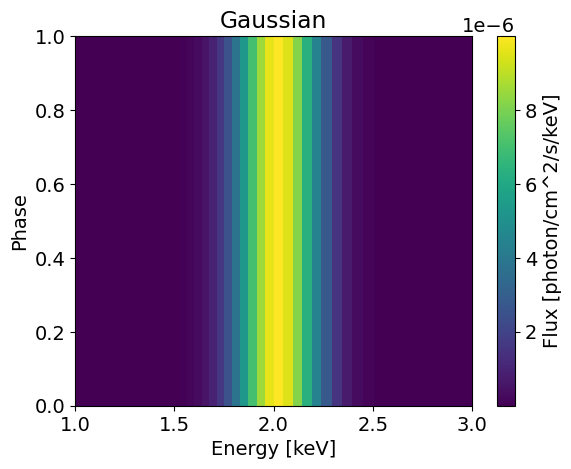

(5,) (50, 5)


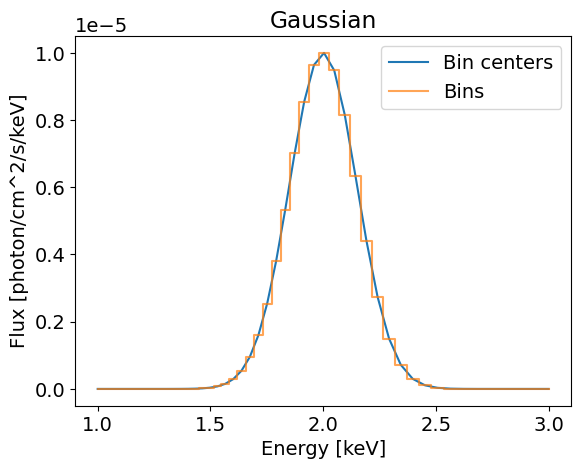

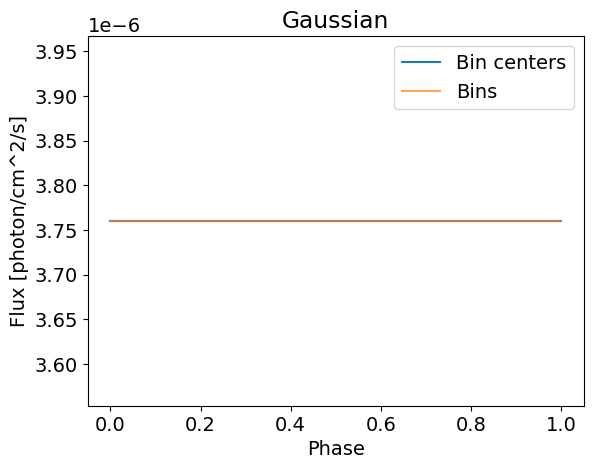

In [10]:
# Integrate the model
energies = np.logspace(0.0, np.log10(3.0), 50)
Gaussian.integrate(energies=energies, threads=1)

# Plot the signal
plotSignal( energies, Gaussian, title='Gaussian' , log=False)

This model is not very complicated and is phase independent. We can build a more general Gaussian model that can be pulsed using the helper functions from the base `EmissionModel` class. Here is an implementation of such a model

In [11]:
from xpsi import Parameter, EmissionModel 
class PulsedGaussianModel( EmissionModel ):

    """ Simple Gaussian line emission model."""

    required_names = ['norm',
                      'E0',
                      'sigma',
                      'phase_shift']
    
    optional_names = ['oscillation_amplitude']
    
    def __init__(self, 
                 bounds,
                 values,
                 pulsed = False,
                 num_leaves = 32,
                 **kwargs):

        # Initiate the necessary parameters
        norm = Parameter('norm',
                        strict_bounds = (0.0, np.infty),
                        bounds = bounds.get('norm', None),
                        doc = "Flux of the Gaussian @E0 keV in [photon/cm^2/s]",
                        symbol = 'norm',
                        value = values.get('norm', None))
        
        E0 = Parameter('E0',
                strict_bounds = (0.0, np.infty),
                bounds = bounds.get('E0', None),
                doc = "Energy center of the Gaussian in [keV]",
                symbol = r'$E_0$',
                value = values.get('E0', None))
        
        sigma = Parameter('sigma',
                strict_bounds = (1e-10, np.infty),
                bounds = bounds.get('sigma', None),
                doc = "Energy width of the Gaussian in [keV]",
                symbol = r'$\sigma$',
                value = values.get('sigma', None))
        
        # Add more if pulsed
        self.is_pulsed = pulsed
        if self.is_pulsed:

            # Define oscillation amplitude parameter
            oscillation_amplitude = Parameter('oscillation_amplitude',
                    strict_bounds = (0. , np.infty),
                    bounds = bounds.get('oscillation_amplitude', None),
                    doc = "Amplitude of oscillation of the Gaussian",
                    symbol = 'A',
                    value = values.get('oscillation_amplitude', None))
            
            # Define phase shift parameter values
            phase_shift_bounds = bounds.get('phase_shift', None)
            phase_shift_value = values.get('phase_shift', None)

            # Define the integration method
            self.integrate = self.integrate_pulsed

        else:

            # Define oscillation amplitude and phase shift parameters values
            oscillation_amplitude = None
            phase_shift_bounds = None
            phase_shift_value = 0.

            # Define the integration method
            self.integrate = self.integrate_phase_independent

        # Define phase shift
        phase_shift = Parameter('phase_shift',
                strict_bounds = (0. , 1.),
                bounds = phase_shift_bounds,
                doc = "Phase shift of the Gaussian",
                symbol = r'$\Delta $\phi_0$',
                value = phase_shift_value)
        
        # Set the value of num_leaves
        self._num_leaves = kwargs.pop('num_leaves', 32) if pulsed else 5 # Default to 5 so that energy integrator works
        self._phases = np.linspace(0.0, 1.0, int(self._num_leaves))

        # Initiate the parent class
        super(PulsedGaussianModel, self).__init__( norm, E0, sigma, oscillation_amplitude, phase_shift, **kwargs ) # prefix in kwargs

    def integrate_phase_independent(self, energies, threads, *args, **kwargs):
        gaussian = self.gaussian(energies)
        self.signal = self.buildPhaseIndependentSignal(gaussian) # Helper function to build the signal in a phase independent way

    def integrate_pulsed(self, energies, threads, *args, **kwargs):
        gaussian = self.gaussian(energies)
        self.signal = self.buildSinusoidalSignal(gaussian) # Helper function to build the signal with a sinusoidal dependence if needed

    def gaussian(self, energies):
        return self['norm'] * np.exp( -0.5 * np.power( (energies - self['E0']) / self['sigma'], 2.0 ) )

Now the pulsed Gaussian model can be instanciated again and then computed for a given set of parameters.

In [12]:
bounds = {}
values = {'norm':1e-5, 
          'E0':2.0,
          'sigma':0.15,
          'phase_shift':0.2,
          'oscillation_amplitude':0.3,
          }
Gaussian = PulsedGaussianModel(bounds=bounds,
                        values=values,
                        num_leaves=64,
                        pulsed=True)

Creating parameter:
    > Named "norm" with fixed value 1.000e-05.
    > Flux of the Gaussian @E0 keV in [photon/cm^2/s].
Creating parameter:
    > Named "E0" with fixed value 2.000e+00.
    > Energy center of the Gaussian in [keV].
Creating parameter:
    > Named "sigma" with fixed value 1.500e-01.
    > Energy width of the Gaussian in [keV].
Creating parameter:
    > Named "oscillation_amplitude" with fixed value 3.000e-01.
    > Amplitude of oscillation of the Gaussian.
Creating parameter:
    > Named "phase_shift" with fixed value 2.000e-01.
    > Phase shift of the Gaussian.


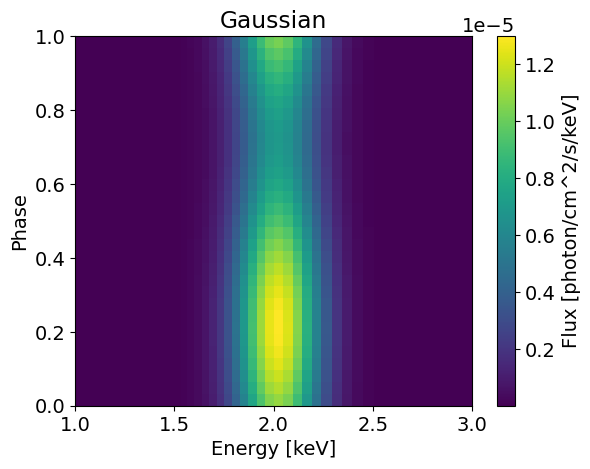

(32,) (50, 32)


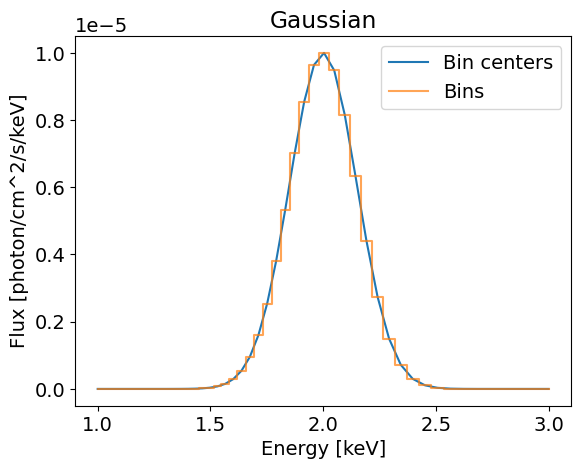

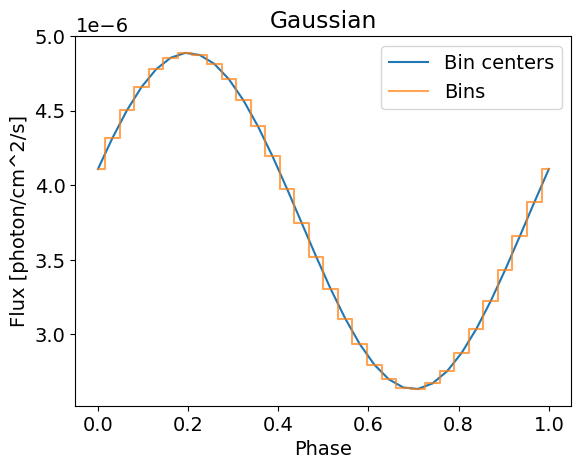

In [13]:
# Integrate the model
energies = np.logspace(0.0, np.log10(3.0), 50)
Gaussian.integrate(energies=energies, threads=1)

# Plot the signal
plotSignal( energies, Gaussian, title='Gaussian' , log=False)

If we want to use this for inference, we need to convolute the integrated signal with the instrument response, and some data to fit. This is done under the hood by X-PSI, and you only need to specify your Emission model in the Likelihood. Let's load this. 

## Prepare X-PSI model

To learn more on emission models, we need to prepare basic X-PSI structures. As these are not the primay focus of this tutorial, we skip precisions. If needed, see `XPSI_101` or `'Modeling` tutorials for more details on this part.

### Load data, instrument files and signal

First, load the dataset we want to model alongside the instrument files. Those are then linked together into a Signal. 

In [14]:
# Load data and instrument. We use txt here because it is lightweight but one should use FITS files if possible
data = xpsi.Data(counts = np.loadtxt('../../examples/example_emission_model/synthetic_PL_pulsed_Gaussian_realisation.dat', dtype=np.double),
                channels=np.arange(30,301),
                phases=np.linspace(0.0, 1.0, 33),
                first=0, last=270,
                exposure_time=2e6,)

NICER = xpsi.Instrument.from_ogip_fits(RMF_path='nicer_20170601v003.rmf',
                                        ARF_path='nicer_20170601v005.arf',
                                        datafolder='../../examples/examples_modeling_tutorial/model_data/',
                                        min_channel=30, max_channel=300)

Setting channels for event data...
Channels set.
Loading instrument response matrix from OGIP compliant files...
Triming the response matrix because it contains rows with only 0 values.
 Now min_energy=0.15000000596046448 and max_energy=20.0
Setting channels for loaded instrument response (sub)matrix...
Channels set.
An empty subspace was created. This is normal behavior - no parameters were supplied.
Response matrix loaded.


In [15]:
# Make signal
from xpsi.likelihoods.default_background_marginalisation import precomputation
from xpsi.likelihoods._poisson_likelihood_given_background import poisson_likelihood_given_background

class CustomSignal(xpsi.Signal):

    def __init__(self, **kwargs):

        super(CustomSignal, self).__init__(**kwargs)

        try:
            self._precomp = precomputation(self._data.counts.astype(np.int32))
        except AttributeError:
            print('Warning: No data... can synthesise data but cannot evaluate a '
                  'likelihood function.')
            
        self._null_poisson_background = np.ascontiguousarray( tuple( np.zeros((271,32)) ) )

    def __call__(self, *args, **kwargs):
        self.loglikelihood, self.expected_counts = \
                poisson_likelihood_given_background(self._data.exposure_time,
                                          self._data.phases,
                                          self._data.counts,
                                          self._signals,
                                          self._phases,
                                          self._shifts,
                                          self._null_poisson_background,
                                          self._precomp,
                                          allow_negative=(False))

signal = CustomSignal(data = data,
                        instrument = NICER,
                        background = None,
                        interstellar = None,
                        workspace_intervals = 1000,
                        cache = True,
                        epsrel = 1.0e-8,
                        epsilon = 1.0e-3,
                        sigmas = 10.0,
                        support = None,
                        tolerance = 1e-6,)

Creating parameter:
    > Named "phase_shift" with fixed value 0.000e+00.
    > The phase shift for the signal, a periodic parameter [cycles].


Here, we setup the Poisson likelihood because we consider one case with only NICER data without background constraint. In this case it is important to use this likelihood as the likelihood with background maginalization will result in wrong parameter inference based on our preliminary test runs. To use the likelihood with background maginalization, it is preferrable to have some background constraints, as samples with the true input parameters could result in lower likelihood (by ~100 log units) than using fully different parameter vectors.

### Spacetime and hotspot

Here, we set up the spacetime and an ST hotspot model.

In [16]:
# Spacetime
bounds = dict(distance = (0.1,10.0),                     # distance in kpc
                mass = (1.0, 2.0),                       # mass with default bounds
                radius = (3.0 * gravradius(1.0), 16.0),  # equatorial radius
                cos_inclination = (0.0, 1.0))            # (Earth) inclination to rotation axis
values = dict(frequency=200.0)                          # Fixed spin frequency
spacetime = xpsi.Spacetime(bounds=bounds, values=values)

Creating parameter:
    > Named "frequency" with fixed value 2.000e+02.
    > Spin frequency [Hz].
Creating parameter:
    > Named "mass" with bounds [1.000e+00, 2.000e+00].
    > Gravitational mass [solar masses].
Creating parameter:
    > Named "radius" with bounds [4.430e+00, 1.600e+01].
    > Coordinate equatorial radius [km].
Creating parameter:
    > Named "distance" with bounds [1.000e-01, 1.000e+01].
    > Earth distance [kpc].
Creating parameter:
    > Named "cos_inclination" with bounds [0.000e+00, 1.000e+00].
    > Cosine of Earth inclination to rotation axis.


In [17]:
# Hotspots
bounds = dict(super_colatitude = (None, None),  # latitude of the hot spot in radians, from north pole (default: 0) to south pole (default: pi)
              super_radius = (None, None),      # radius of the hot spot, in radians (default: between 0 and pi/2 (half of the NS))
              phase_shift = (-0.25, 0.75),      # longitude of the hot spot
              super_temperature = (None, None)) # temperature of the hot spot, default: 3.0 to 7.6, from very cold to very hot
values = {} 

# a simple circular, simply-connected spot
primary = xpsi.HotRegion(bounds=bounds,
                        values=values, # no initial values and no derived/fixed values
                        symmetry=True,
                        omit=False,
                        cede=False,
                        concentric=False,
                        sqrt_num_cells=32,
                        min_sqrt_num_cells=10,
                        max_sqrt_num_cells=64,
                        num_leaves=64,
                        num_rays=200,
                        atm_ext="BB", # default blackbody, other options: "Num4D" or "user"
                        prefix='p')   # unique prefix to identify the region, needed if >1 instances

Creating parameter:
    > Named "super_colatitude" with bounds [0.000e+00, 3.142e+00].
    > The colatitude of the centre of the superseding region [radians].
Creating parameter:
    > Named "super_radius" with bounds [0.000e+00, 1.571e+00].
    > The angular radius of the (circular) superseding region [radians].
Creating parameter:
    > Named "phase_shift" with bounds [-2.500e-01, 7.500e-01].
    > The phase of the hot region, a periodic parameter [cycles].
Creating parameter:
    > Named "super_temperature" with bounds [3.000e+00, 7.600e+00].
    > log10(superseding region effective temperature [K]).


In [18]:
# Photosphere and star
photosphere = xpsi.Photosphere(hot = primary, elsewhere = None,
                                values=dict(mode_frequency = spacetime['frequency']))

star = xpsi.Star(spacetime = spacetime, photospheres = photosphere)

Creating parameter:
    > Named "mode_frequency" with fixed value 2.000e+02.
    > Coordinate frequency of the mode of radiative asymmetry in the
photosphere that is assumed to generate the pulsed signal [Hz].


## New emission models

Now, we instantiate emission models. Let's use a pulsed power law and a gaussian. They can be instantiated like before.

### Powerlaw

In [19]:
bounds = {'norm':(0.0,1e0), 
          'gamma':(1.0,2.0), 
          'oscillation_amplitude':(0.0,1.0), 
          'phase_shift':(0.0,1.0)
          }
values = {}
PowerLaw = xpsi.PowerLaw(bounds=bounds,
                        values=values,
                        pulsed=True,    # Requires the model to be pulsed
                        num_leaves=128,  # Number of phase bins to use for model computation
                        prefix='pl'
                        )

Creating parameter:
    > Named "norm" with bounds [0.000e+00, 1.000e+00].
    > Normalization of the PowerLaw in photons/cm2/s/keV @ 1keV.
Creating parameter:
    > Named "gamma" with bounds [1.000e+00, 2.000e+00].
    > Photon index of the PowerLaw.
Creating parameter:
    > Named "oscillation_amplitude" with bounds [0.000e+00, 1.000e+00].
    > Amplitude of oscillation of the PowerLaw.
Creating parameter:
    > Named "phase_shift" with bounds [0.000e+00, 1.000e+00].
    > Phase shift of the PowerLaw.


In [20]:
bounds = {'norm':(0.0,1.0), 
          'E0':(1.0,3.0),
          'sigma':(1e-5,1.0),
          }
values = {}
Gaussian = GaussianModel(bounds=bounds,
                        values=values,
                        prefix='gauss')

Creating parameter:
    > Named "norm" with bounds [0.000e+00, 1.000e+00].
    > Flux of the Gaussian @E0 keV in [photon/cm^2/s/keV].
Creating parameter:
    > Named "E0" with bounds [1.000e+00, 3.000e+00].
    > Energy center of the Gaussian in [keV].
Creating parameter:
    > Named "sigma" with bounds [1.000e-05, 1.000e+00].
    > Energy width of the Gaussian in [keV].
Creating parameter:
    > Named "phase_shift" with fixed value 0.000e+00.
    > Phase shift of the Gaussian.


### Prior and likelihood

Now we make the prior and the likelihood. The `PowerLaw` model needs to be given in input to the likelihood.

In [21]:
# Prior
class CustomPrior(xpsi.Prior):
    """ A custom (joint) prior distribution. """

    __derived_names__ = ['compactness', ]
    __draws_from_support__ = 3

    def __init__(self):
        super(CustomPrior, self).__init__() # not strictly required if no hyperparameters

    def __call__(self, p = None):
        """ Evaluate distribution at ``p``"""

        temp = super(CustomPrior, self).__call__(p)
        if not np.isfinite(temp):
            return temp

        # based on contemporary EOS theory
        if not self.parameters['radius'] <= 16.0:
            return -np.inf

        ref = self.parameters.star.spacetime # shortcut

        # limit polar radius to try to exclude deflections >= \pi radians
        R_p = 1.0 + ref.epsilon * (-0.788 + 1.030 * ref.zeta)
        if R_p < 1.76 / ref.R_r_s:
            return -np.inf
        
        # 2-surface cross-section have a single maximum in |z|
        # i.e., an elliptical surface; minor effect on support, if any,
        # for high spin frequenies
        mu = math.sqrt(-1.0 / (3.0 * ref.epsilon * (-0.788 + 1.030 * ref.zeta)))
        if mu < 1.0:
            return -np.inf

        ref = self.parameters # redefine shortcut

        return 0.0

    def inverse_sample(self, hypercube=None):
        """ Draw sample uniformly from the distribution via inverse sampling. """

        to_cache = self.parameters.vector

        if hypercube is None:
            hypercube = np.random.rand(len(self))

        # the base method -a uniform sampling within the bounds- is useful, so to avoid writing that code again:
        _ = super(CustomPrior, self).inverse_sample(hypercube)

        ref = self.parameters # shortcut

        # flat priors in cosine of hot region centre colatitudes (isotropy)
        # support modified by no-overlap rejection condition
        idx = ref.index('p__super_colatitude')
        a, b = ref.get_param('p__super_colatitude').bounds
        a = math.cos(a); b = math.cos(b)
        ref['p__super_colatitude'] = math.acos(b + (a - b) * hypercube[idx])

        # restore proper cache
        for parameter, cache in zip(ref, to_cache):
            parameter.cached = cache
            
        return self.parameters.vector
    
    def transform(self, p, **kwargs):
        """ A transformation for post-processing. """

        p = list(p) # copy

        return p

In [22]:
# Build prior and likelihood
prior = CustomPrior()
likelihood = xpsi.Likelihood(star = star, signals = signal,
                             emission_models = PowerLaw,        # Put here the emission model, or a list of emission models
                             prior = prior,
                             num_energies=64,
                             threads=1,
                             externally_updated=True)

likelihood

An empty subspace was created. This is normal behavior - no parameters were supplied.


Free parameters
---------------
mass: Gravitational mass [solar masses].
radius: Coordinate equatorial radius [km].
distance: Earth distance [kpc].
cos_inclination: Cosine of Earth inclination to rotation axis.
p__phase_shift: The phase of the hot region, a periodic parameter [cycles].
p__super_colatitude: The colatitude of the centre of the superseding region [radians].
p__super_radius: The angular radius of the (circular) superseding region [radians].
p__super_temperature: log10(superseding region effective temperature [K]).
pl__norm: Normalization of the PowerLaw in photons/cm2/s/keV @ 1keV.
pl__gamma: Photon index of the PowerLaw.
pl__oscillation_amplitude: Amplitude of oscillation of the PowerLaw.
pl__phase_shift: Phase shift of the PowerLaw.

Alternatively, we can also use multiple emission models at once. You need to put them in a list. For instance:

In [23]:
# Build prior and likelihood
prior = CustomPrior()
likelihood = xpsi.Likelihood(star = star, signals = signal,
                             emission_models = [PowerLaw, Gaussian],        # Put here the emission model, or a list of emission models
                             prior = prior,
                             num_energies=64,
                             threads=1,
                             externally_updated=False)
likelihood

An empty subspace was created. This is normal behavior - no parameters were supplied.


Free parameters
---------------
mass: Gravitational mass [solar masses].
radius: Coordinate equatorial radius [km].
distance: Earth distance [kpc].
cos_inclination: Cosine of Earth inclination to rotation axis.
p__phase_shift: The phase of the hot region, a periodic parameter [cycles].
p__super_colatitude: The colatitude of the centre of the superseding region [radians].
p__super_radius: The angular radius of the (circular) superseding region [radians].
p__super_temperature: log10(superseding region effective temperature [K]).
pl__norm: Normalization of the PowerLaw in photons/cm2/s/keV @ 1keV.
pl__gamma: Photon index of the PowerLaw.
pl__oscillation_amplitude: Amplitude of oscillation of the PowerLaw.
pl__phase_shift: Phase shift of the PowerLaw.
gauss__norm: Flux of the Gaussian @E0 keV in [photon/cm^2/s/keV].
gauss__E0: Energy center of the Gaussian in [keV].
gauss__sigma: Energy width of the Gaussian in [keV].

In [24]:
# Likelihood check
p = [1.4,      # mass
     12.0,     # radius 
     1.0,      # distance
     0.4,      # cos_inclination
     0.1,      # p__phase_shift
     0.9,      # p__super_colatitude
     0.2,      # p__super_radius
     6.15,     # p__super_temperature
     1e-3,      # pl__norm
     1.5,      # pl__gamma
     0.4,      # pl__oscillation_amplitude
     0.1,       # pl__phase
     5e-4,      # gauss__norm
     2.0,      # gauss__E0
     0.3,      # gauss__sigma
     ]

## Or check that you get the expected likelihood value
likelihood( p=p, reinitialise=True )
likelihood.check(None, [-40055.27257076219], 1.0e-6,
                 physical_points=[p])

Checking likelihood and prior evaluation before commencing sampling...
Not using ``allclose`` function from NumPy.
Using fallback implementation instead.
Checking closeness of likelihood arrays:
-4.0055272571e+04 | -4.0055272571e+04 .....
Closeness evaluated.
Log-likelihood value checks passed on root process.
Checks passed.


'Log-likelihood value checks passed on root process.'

Text(0, 0.5, 'Counts')

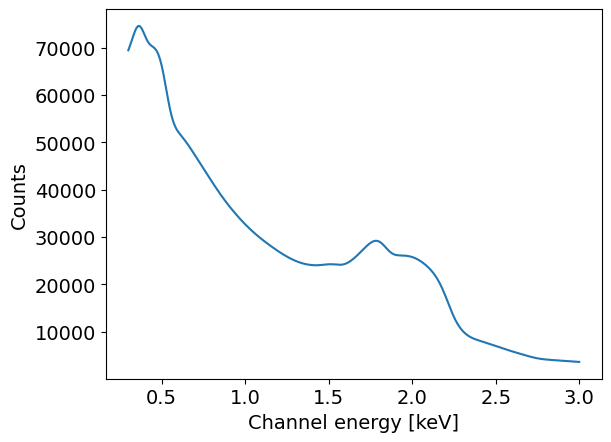

In [25]:
plt.plot( likelihood.signal.instrument.channel_edges[:-1], likelihood.signal.expected_counts.sum(axis=1))
plt.xlabel('Channel energy [keV]')
plt.ylabel('Counts')

You can access the signal from the emission models like you do for hot spots. The emission models signals are appended to the hot spot signals. These are in photons/cm2/s, and can be accessed like so:

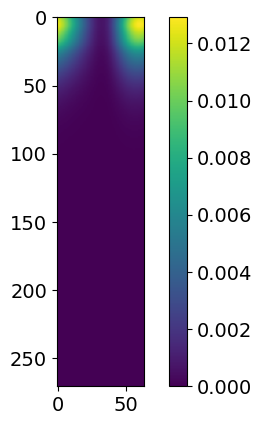

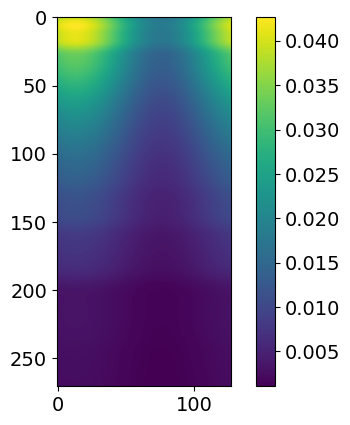

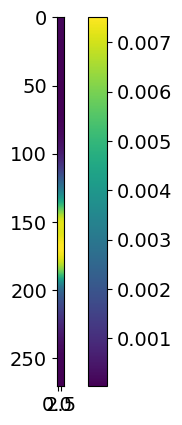

In [26]:
for i in range(3):
    plt.imshow( likelihood.signal.signals[i] )
    plt.colorbar()
    plt.show()

These signals plotted here represent, in order, hot region, power law and gaussian. If you were to have a second hot region, it would show up as an extra plot here.

Once the emission model is linked to the likelihood, it is possible to access the spacetime parameters values from the emission models, the same way as it is done in the prior, with `self.parameters`.

Contrary to hot spot models, the flux is not divided by the square of the distance to the source in our case. If the user wishes to have such division occur, it can be done with something like this in the integrate method:

```
d_sq = self.parameters._star.spacetime.d_sq
integrated_signal = integrated_signal / d_sq
```

Here is a short example on how to access it

In [27]:
for m in likelihood.emission_models:
    print( m.parameters._star.spacetime.d_sq )

9.521406127714657e+38
9.521406127714657e+38


## Sampling and Post-Processing

Sampling and Post-Processing are the exact sames as without emission models. Do not forget to add your phase shift (and other necessary parameters) as wrapped parameters while sampling.

In [28]:
wrapped_params = [0]*len(likelihood)
wrapped_params[likelihood.index('p__phase_shift')] = 1
wrapped_params[likelihood.index('pl__phase_shift')] = 1

The following code block is commented as it will be long to run before you obtain satisfactory results.

In [29]:
# likelihood.externally_updated = True
# runtime_params = {'resume': False,
#                   'importance_nested_sampling': False,
#                   'multimodal': False,
#                   'n_clustering_params': None,
#                   'outputfiles_basename': './output/run_PL_Gauss/', # make ./Output directory manually
#                   'n_iter_before_update': 5,
#                   'n_live_points': 500,
#                   'sampling_efficiency': 0.8,
#                   'const_efficiency_mode': False,
#                   'wrapped_params': wrapped_params,
#                   'evidence_tolerance': 0.5,
#                   'verbose': True}
# xpsi.Sample.run_multinest(likelihood, prior, **runtime_params)

## Synthesize data

It can be interesting to synthesize data with your emission model to inspect what it looks like as seen through your instrument. It is also useful to test parameter recovery. Once again, this is done similarly as without the emission model.

In [30]:
# Load data and instrument
data = xpsi.Data(counts = np.ones((271, 32), dtype=np.double),
                channels=np.arange(30,301),
                phases=np.linspace(0.0, 1.0, 33),
                first=0, last=270,
                exposure_time=1.0,)

NICER = xpsi.Instrument.from_ogip_fits(RMF_path='nicer_20170601v003.rmf',
                                        ARF_path='nicer_20170601v005.arf',
                                        datafolder='../../examples/examples_modeling_tutorial/model_data/')

Setting channels for event data...
Channels set.
Loading instrument response matrix from OGIP compliant files...
Triming the response matrix because it contains columns with only 0 values.
 Now min_channel=9 and max_channel=1500
Setting channels for loaded instrument response (sub)matrix...
Channels set.
An empty subspace was created. This is normal behavior - no parameters were supplied.
Response matrix loaded.


In [31]:
# Make signal
from xpsi.likelihoods._poisson_likelihood_given_background import poisson_likelihood_given_background
from xpsi.likelihoods.default_background_marginalisation import precomputation
from xpsi.tools.synthesise import synthesise_exposure as _synthesise_expo
from astropy.io import fits

class CustomSignal(xpsi.Signal):

    def __init__(self, **kwargs):

        super(CustomSignal, self).__init__(**kwargs)

        try:
            self._precomp = precomputation(self._data.counts.astype(np.int32))
        except AttributeError:
            print('Warning: No data... can synthesise data but cannot evaluate a '
                  'likelihood function.')
            
        self._null_poisson_background = np.ascontiguousarray( tuple( np.zeros((271,32)) ) )

    def __call__(self, *args, **kwargs):
        self.loglikelihood, self.expected_counts = \
                poisson_likelihood_given_background(self._data.exposure_time,
                                          self._data.phases,
                                          self._data.counts,
                                          self._signals,
                                          self._phases,
                                          self._shifts,
                                          self._null_poisson_background,
                                          self._precomp,
                                          allow_negative=(False))

    def synthesise(self,
                exposure_time,
                data_BKG,
                instrument_name,
                backscal_ratio=1.0,
                name='synthetic',
                directory='./',
                seed=None,
                **kwargs):

            # Create or find directory
            try:
                if not os.path.isdir(directory):
                    os.mkdir(directory)
            except OSError:
                print('Cannot create write directory.')
                raise

            # Rescale background
            rescaled_background = data_BKG / backscal_ratio
            expected_background_counts = rescaled_background.sum()
            background_txt = rescaled_background.flatten()

            # Make the phase resolved background (constant for all phases but needed for _synthesise_expo)
            background_syn = np.zeros((len(self._data.channels),len(self._data.phases)-1))      
            for j in range(len(self._data.phases)-1):
                background_syn[:,j] = background_txt/(len(self._data.phases)-1)

            # Synthesise
            self._expected_counts, synthetic, _  = _synthesise_expo(exposure_time,
                                                                self._data.phases,
                                                                self._signals,
                                                                self._phases,
                                                                self._shifts,
                                                                expected_background_counts,
                                                                background_syn,
                                                                gsl_seed=seed)

            # Write expected counts
            kwargs = {'channels':self._data.channels,
                    'counts':self._expected_counts,
                    'filename':os.path.join(directory, name),
                    'instrument':instrument_name,
                    'exposure':exposure_time,
                    'backscale':1.0}
            self._write_EVT(**kwargs)

            # Write synthetic counts (Poisson realisation of expected counts)
            kwargs['counts'] = synthetic
            kwargs['filename'] += '_realization'
            self._write_EVT(**kwargs)

    def _write_EVT(self, 
                channels,
                counts,
                filename,
                instrument,
                exposure, 
                backscale ):

        # Create the header
        header = {
            'INSTRUME': instrument, 
            'HDUCLAS1': 'EVENTS',
            'HDUCLAS2': 'none',
            'DATE': '2025-07-31',
            'EXPOSURE': exposure,
            'BACKSCAL': backscale,
            'ANCRFILE': 'none',
            'RESPFILE': 'none'
        }

        # Get the phase array
        phase_borders = np.linspace( 0., 1., counts.shape[1]+1 )
        phase_centers = (phase_borders[1:] + phase_borders[:-1]) / 2
        PI, PULSE_PHASE = [], []

        # Fill the arrays
        for i in range(counts.shape[0]):
            for j in range(counts.shape[1]):
                for k in range( int(counts[i,j]) ):
                    PI.append( channels[i] )
                    PULSE_PHASE.append( phase_centers[j] )

        # Create the columns
        cols = [
            fits.Column(name='PI', array=np.array(PI), format='1J'),
            fits.Column(name='PULSE_PHASE', array=np.array(PULSE_PHASE), format='D'),
        ]

        # Create a primary HDU (header/data unit) for the header info
        primary_hdu = fits.PrimaryHDU()
        bin_table = fits.BinTableHDU.from_columns(cols, name='EVENTS')

        # Set header keywords
        for key, value in header.items():
            bin_table.header[key] = value

        # Create the FITS file (PHA file)
        hdul = fits.HDUList([primary_hdu, bin_table])

        # Save to a PHA file
        hdul.writeto(filename+'.evt', overwrite=True)

In [32]:
signal = CustomSignal(data = data,
                        instrument = NICER,
                        background = None,
                        interstellar = None,
                        workspace_intervals = 1000,
                        cache = True,
                        epsrel = 1.0e-8,
                        epsilon = 1.0e-3,
                        sigmas = 10.0,
                        support = None,
                        tolerance = 1e-4,
                        prefix='NICER')

# Build prior and likelihood
prior = CustomPrior()
likelihood = xpsi.Likelihood(star = star, signals = signal,
                             emission_models = [PowerLaw, Gaussian],        # Put here the emission model, or a list of emission models
                             prior = prior,
                             num_energies=128,
                             threads=1,
                             externally_updated=False)

p = [1.4,      # mass
     12.0,     # radius 
     1.0,      # distance
     0.4,      # cos_inclination
     0.1,      # p__phase_shift
     0.9,      # p__super_colatitude
     0.2,      # p__super_radius
     6.15,     # p__super_temperature
     1e-3,      # pl__norm
     1.5,      # pl__gamma
     0.4,      # pl__oscillation_amplitude
     0.1,       # pl__phase
     5e-4,      # gauss__norm
     2.0,      # gauss__E0
     0.3,      # gauss__sigma
     ]
likelihood( p , reinitialise=True )

Creating parameter:
    > Named "phase_shift" with fixed value 0.000e+00.
    > The phase shift for the signal, a periodic parameter [cycles].
An empty subspace was created. This is normal behavior - no parameters were supplied.


-70210.16386158185

In [33]:
NICER_kwargs = dict(exposure_time=2e6,
                    data_BKG=np.zeros((271,)),
                    instrument_name='NICER',
                    name='synthetic_PL_pulsed_Gaussian',
                    directory='./data',
                    seed=42)

likelihood.synthesise(p, force=True, NICER=NICER_kwargs)

Now we can load this data to see if it was well synthesized

Loading event list and phase binning...
Setting channels for event data...
Channels set.
Events loaded and binned.


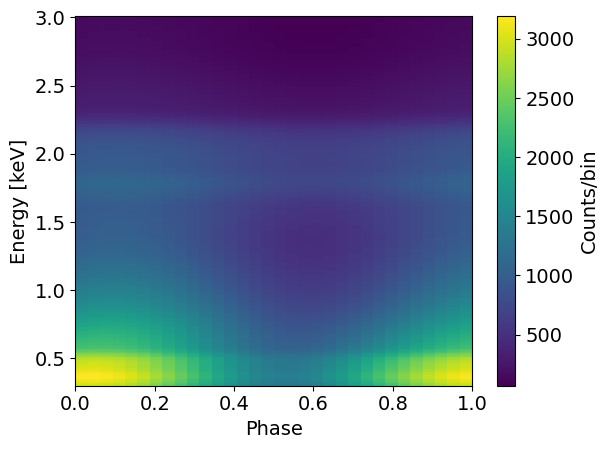

Text(0, 0.5, 'Counts')

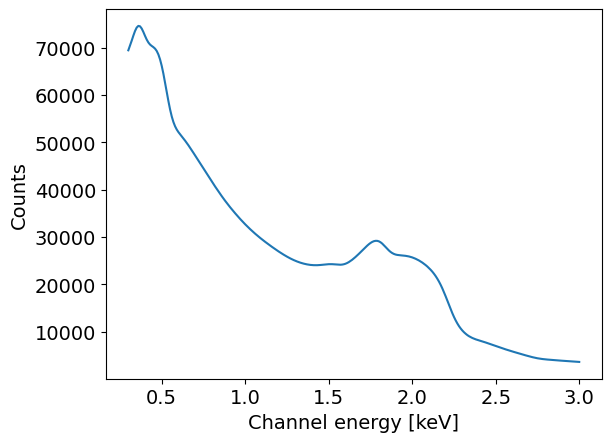

In [34]:
newData = xpsi.Data.from_evt( './data/synthetic_PL_pulsed_Gaussian.evt' )
energies = likelihood.signal.instrument.channel_edges[21:293]
phases = likelihood.signal.data.phases
plt.pcolormesh( phases, energies, newData.counts )
plt.xlabel('Phase')
plt.ylabel('Energy [keV]')
plt.colorbar(label='Counts/bin')
plt.show()

plt.plot( energies[:-1] , newData.counts.sum(axis=1) )
plt.xlabel('Channel energy [keV]')
plt.ylabel('Counts')